That's not a prablem notebook is already empty

In [27]:
print("try")

try


In [28]:
import numpy as np 


random_array = np.random.rand(4, 3) *  10
print(random_array)

[[6.65862216 3.12501329 2.65601202]
 [7.99662242 1.2170193  2.03573288]
 [5.95435898 0.445278   3.4967055 ]
 [9.15815982 8.36741554 9.07438211]]


the reason we change the shape is 
sckit learn expected to see 2d training values and 1d output values since thats the case when we give it numpy arrays it gives 
ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.
inorder to get a single column  as a 2d object u can use double [] 
like pd.loc[:, ['series name']] that gives the 1 dimensional array as a 2d frame


In [ ]:
from sklearn.datasets import load_diabetes


X,y = load_diabetes(return_X_y=True)
print(type(X))
print(type(y))
print(X[:5])
print(y[:5])


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
[151.  75. 141. 206. 135.]


in order to use a numpy array as training data we need to make it 2d with reshape(-1,1)

In [57]:

from sklearn.model_selection import train_test_split


X = X[:, [2]]  # BMI Column
X = X.reshape(-1, 1)  # inorder to use as a training data it has to be 2d
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:

from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[998.58]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[0.89]


In [59]:
predictions = model.predict(X_test)

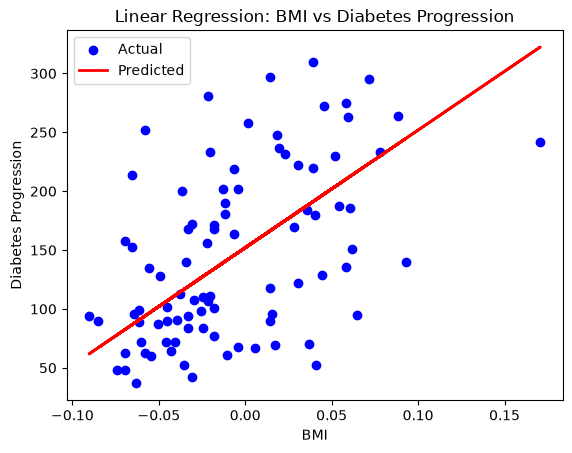

In [61]:
import matplotlib.pyplot as plt
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, predictions, color='red', linewidth=2, label='Predicted')
plt.xlabel('BMI')
plt.ylabel('Diabetes Progression')
plt.title('Linear Regression: BMI vs Diabetes Progression')
plt.legend()
plt.show()